# BDTs to separate the signal from double charm backgrounds

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

In [3]:
from sklearn.model_selection import train_test_split

train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

def prepare_data(category):
    df_signal = load_signal_all()
    df_background = load_background_category(category)

    df_background= shuffle(df_background)
    df_signal = shuffle(df_signal)

    df = pd.concat([df_signal,df_background], axis=0)
    df = shuffle(df)
    
    train, test = train_test_split(df, test_size=0.2)
    
    Xtrain = train[train_columns]
    ytrain = train["signal"]
    Xtest = test[train_columns]
    ytest = test["signal"]
    
    from sklearn import preprocessing
    scaler = preprocessing.StandardScaler().fit(Xtrain)
    Xtrain_scaled = scaler.transform(Xtrain)
    Xtest_scaled = scaler.transform(Xtest)
    
    return (Xtrain, ytrain, Xtest, ytest, scaler, Xtrain_scaled, Xtest_scaled)

def train_classifier(Xtrain_sscaled, ytrain, Xtest_scaled, ytest):

    # Create classifier
    ratio = len(ytrain[ytrain==0]) / len(ytrain[ytrain==1])
    print(f"Ratio bkg=/sign is {ratio}")
    model = xgb.XGBClassifier( eval_metric='logloss', 
                          n_estimators=200, eta=0.03, scale_pos_weight=ratio)
    xgbclass = make_pipeline(scaler, model)
    print(model)
    
    # doing the training
    evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)
    return model, res, xgbclass

def check_classifier(model, Xtest, ytest):
    results = model.evals_result()
    # plot learning curves
    plt.plot(results['validation_0']['logloss'], label='train')
    plt.plot(results['validation_1']['logloss'], label='test')
    # show the legend
    plt.legend()
    # show the plot
    plt.ylabel("logloss")
    plt.xlabel("training iteration")
    plt.show()
    
    yscore = xgbclass.predict_proba(Xtest)
    ypred = xgbclass.predict(Xtest)
    accuracy = accuracy_score(ytest, ypred)
    print('Accuracy: %.3f' % accuracy)
    
    from sklearn.metrics import RocCurveDisplay
    from sklearn.metrics import roc_curve, auc
    yscore = xgbclass.predict_proba(Xtest)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

    # ROC curve 
    #RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
    fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    ax2.plot(1 - fpr, tpr)
    ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
    print(roc_auc)

    # Classifier output
    ax1.set_title(f"XGBoost Classifier output")
    t = 'step'
    n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
    ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
    ax1.legend();
    
    
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    confusion_matrix(ytest, ypred)
    class_names = [ "background", "signal"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
    ConfusionMatrixDisplay.from_estimator(
            model,
            Xtest_scaled,
            ytest,
            display_labels = class_names,
            cmap=plt.cm.Blues,
            normalize='all',
            ax = ax1
        );
    ConfusionMatrixDisplay.from_estimator(
            model,
            Xtest_scaled,
            ytest,
            display_labels = class_names,
            cmap=plt.cm.Blues,
            normalize=None,
            ax = ax2
        )
    
    plt.figure()
    plt.barh(Xtrain.columns, model.feature_importances_);

# Classifier to separate signal and BsDs background

Ratio bkg=/sign is 11.133647483456988
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.03, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)
[0]	validation_0-logloss:0.67741	validation_1-logloss:0.67736
[1]	validation_0-logloss:0.66258	validation_1-logloss:0.66249
[2]	validation_0-logloss:0.64857	validation_1-logloss:0.64845
[3]	validation_0-logloss:0.6

[118]	validation_0-logloss:0.25637	validation_1-logloss:0.26136
[119]	validation_0-logloss:0.25568	validation_1-logloss:0.26078
[120]	validation_0-logloss:0.25495	validation_1-logloss:0.26012
[121]	validation_0-logloss:0.25423	validation_1-logloss:0.25950
[122]	validation_0-logloss:0.25358	validation_1-logloss:0.25891
[123]	validation_0-logloss:0.25286	validation_1-logloss:0.25827
[124]	validation_0-logloss:0.25217	validation_1-logloss:0.25764
[125]	validation_0-logloss:0.25144	validation_1-logloss:0.25703
[126]	validation_0-logloss:0.25084	validation_1-logloss:0.25653
[127]	validation_0-logloss:0.25012	validation_1-logloss:0.25591
[128]	validation_0-logloss:0.24950	validation_1-logloss:0.25536
[129]	validation_0-logloss:0.24890	validation_1-logloss:0.25487
[130]	validation_0-logloss:0.24836	validation_1-logloss:0.25439
[131]	validation_0-logloss:0.24775	validation_1-logloss:0.25385
[132]	validation_0-logloss:0.24715	validation_1-logloss:0.25333
[133]	validation_0-logloss:0.24658	valid

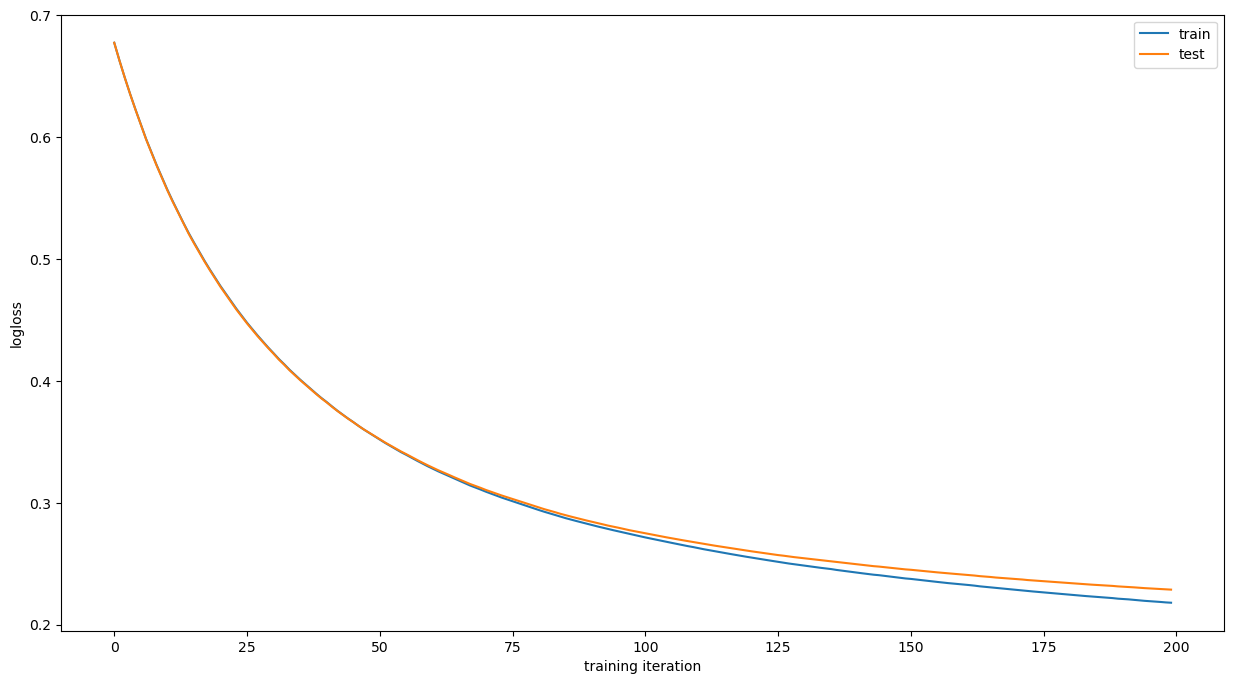

Accuracy: 0.910
0.9591898311750289
CPU times: user 11min 36s, sys: 6.55 s, total: 11min 43s
Wall time: 4min 1s


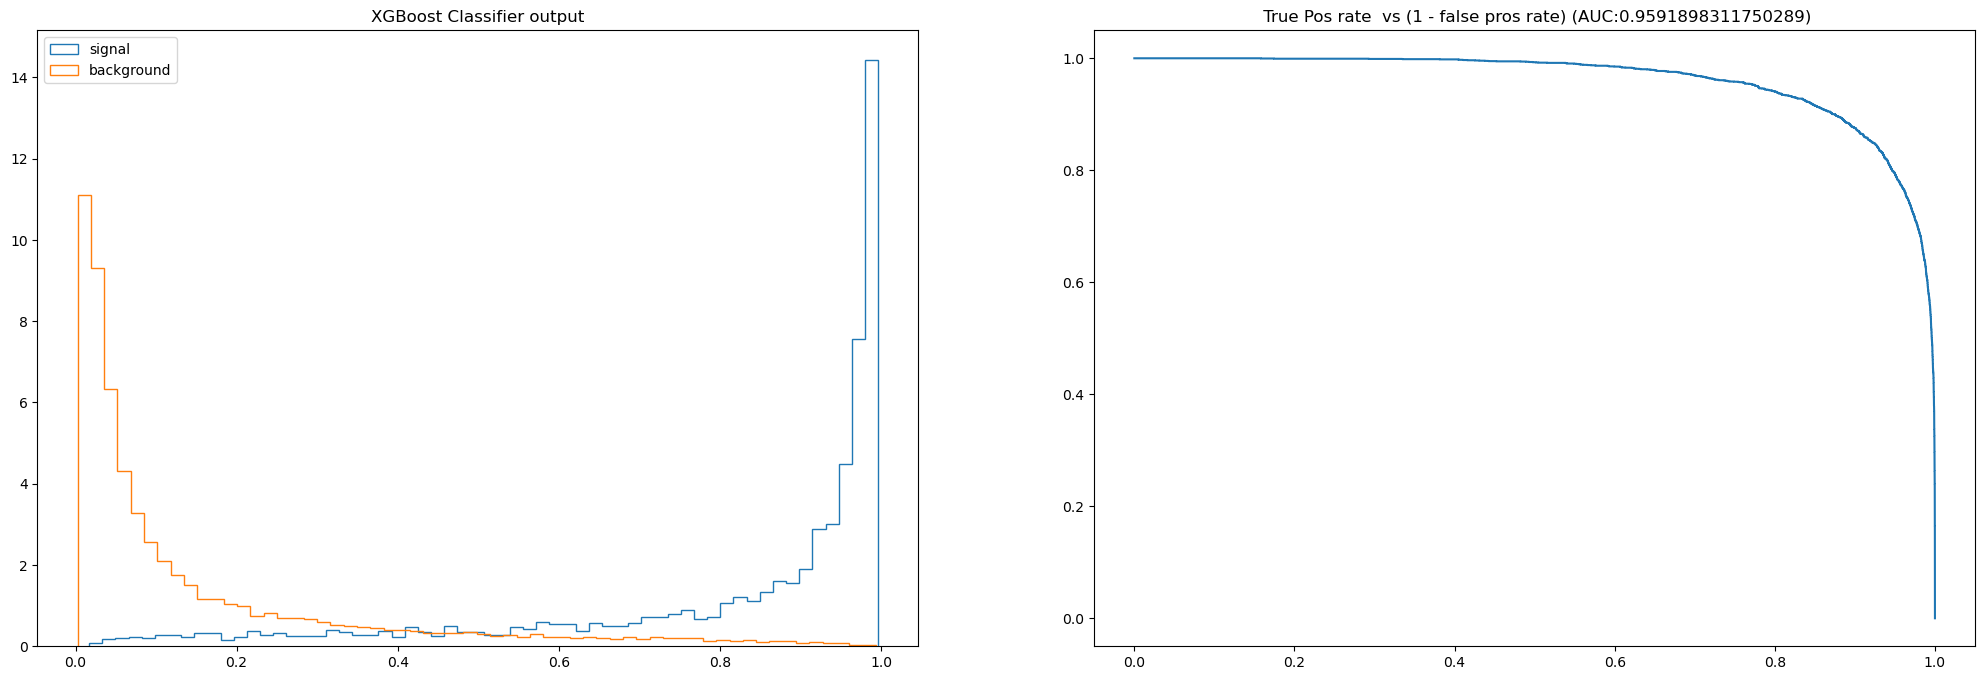

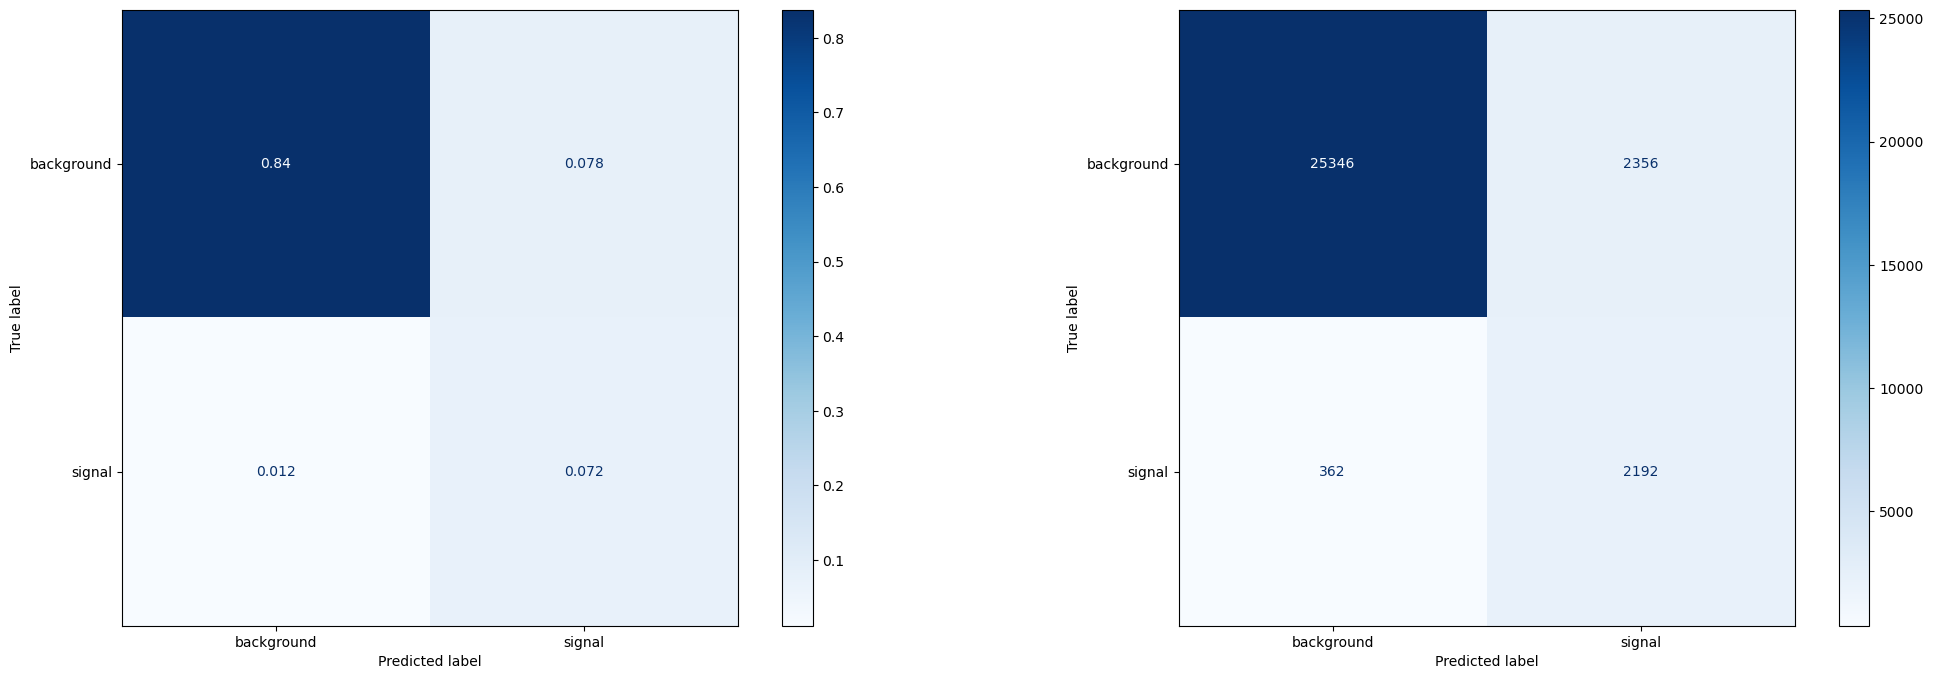

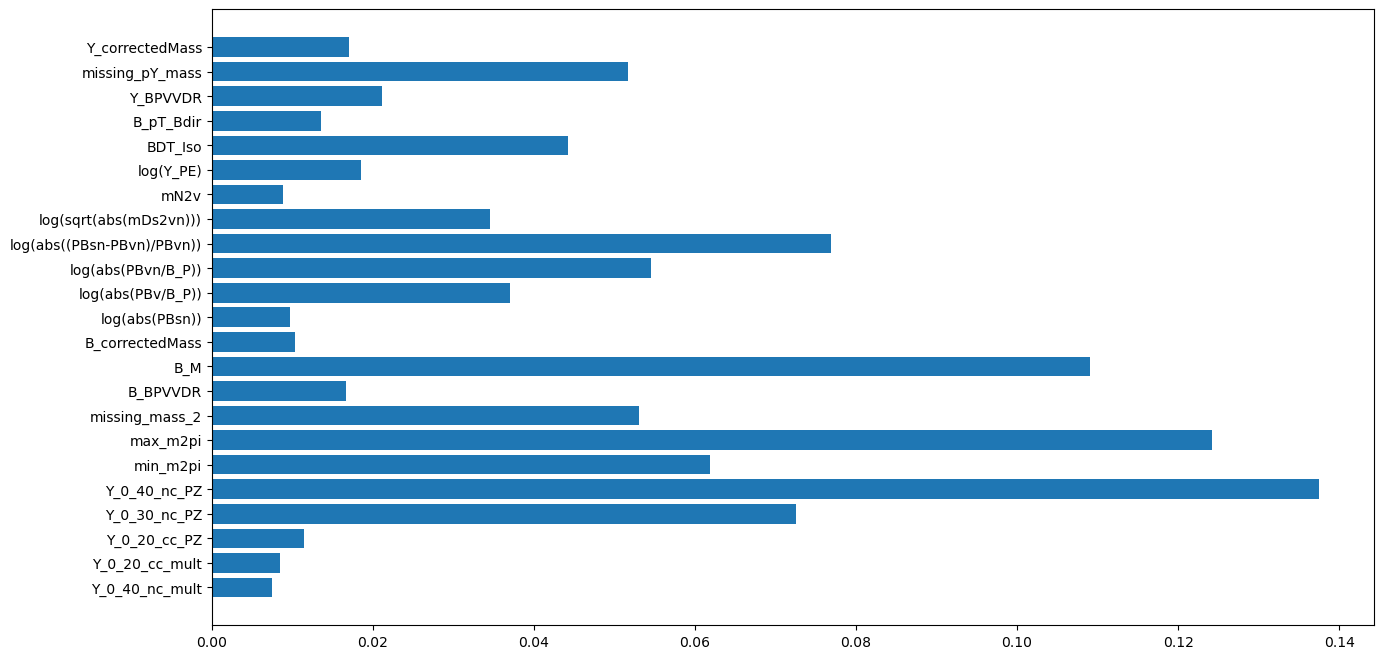

In [4]:
%%time
(Xtrain, ytrain, Xtest, ytest, scaler, Xtrain_scaled, Xtest_scaled) = prepare_data(18)
model, res, xgbclass = train_classifier(Xtrain_scaled, ytrain, Xtest_scaled, ytest)
check_classifier(model, Xtest, ytest)

# Category 19

Ratio bkg=/sign is 10.911664665866347
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.03, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)
[0]	validation_0-logloss:0.68373	validation_1-logloss:0.68383
[1]	validation_0-logloss:0.67484	validation_1-logloss:0.67508
[2]	validation_0-logloss:0.66639	validation_1-logloss:0.66674
[3]	validation_0-logloss:0.6

[118]	validation_0-logloss:0.40272	validation_1-logloss:0.41197
[119]	validation_0-logloss:0.40205	validation_1-logloss:0.41139
[120]	validation_0-logloss:0.40097	validation_1-logloss:0.41041
[121]	validation_0-logloss:0.40017	validation_1-logloss:0.40968
[122]	validation_0-logloss:0.39937	validation_1-logloss:0.40899
[123]	validation_0-logloss:0.39876	validation_1-logloss:0.40848
[124]	validation_0-logloss:0.39814	validation_1-logloss:0.40793
[125]	validation_0-logloss:0.39727	validation_1-logloss:0.40713
[126]	validation_0-logloss:0.39662	validation_1-logloss:0.40657
[127]	validation_0-logloss:0.39593	validation_1-logloss:0.40591
[128]	validation_0-logloss:0.39494	validation_1-logloss:0.40501
[129]	validation_0-logloss:0.39417	validation_1-logloss:0.40435
[130]	validation_0-logloss:0.39357	validation_1-logloss:0.40382
[131]	validation_0-logloss:0.39262	validation_1-logloss:0.40300
[132]	validation_0-logloss:0.39187	validation_1-logloss:0.40237
[133]	validation_0-logloss:0.39115	valid

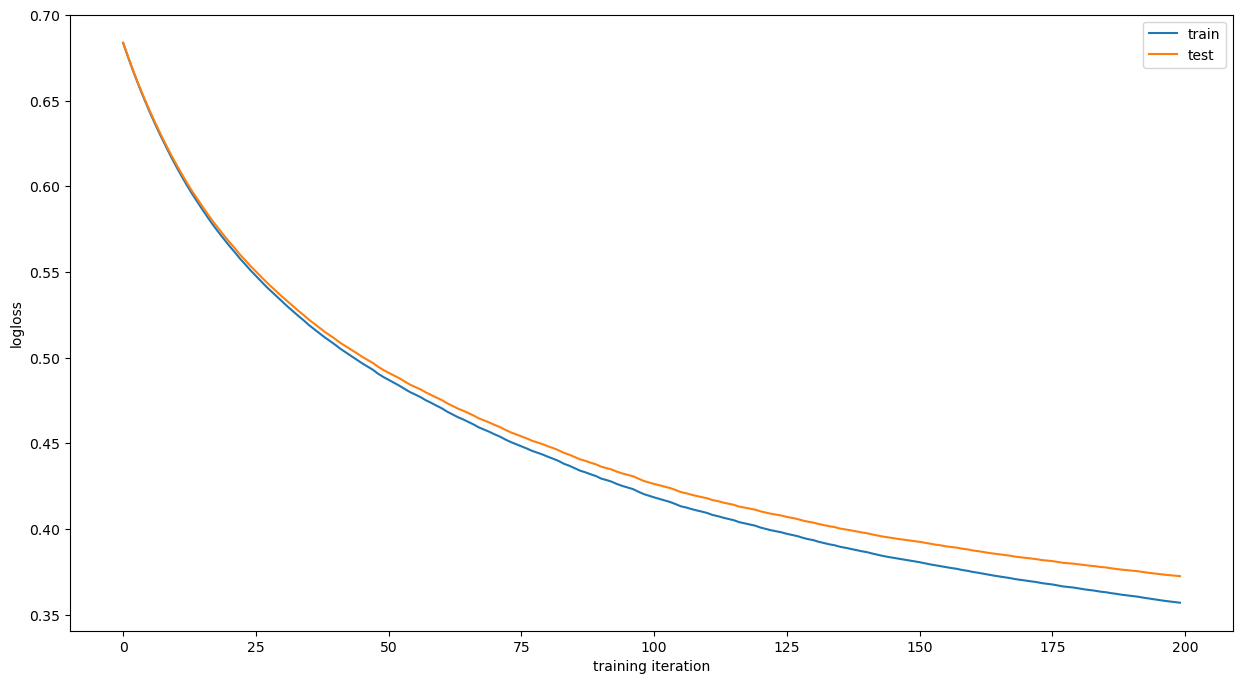

Accuracy: 0.838
0.9040320467265585
CPU times: user 2min 54s, sys: 706 ms, total: 2min 54s
Wall time: 50.2 s


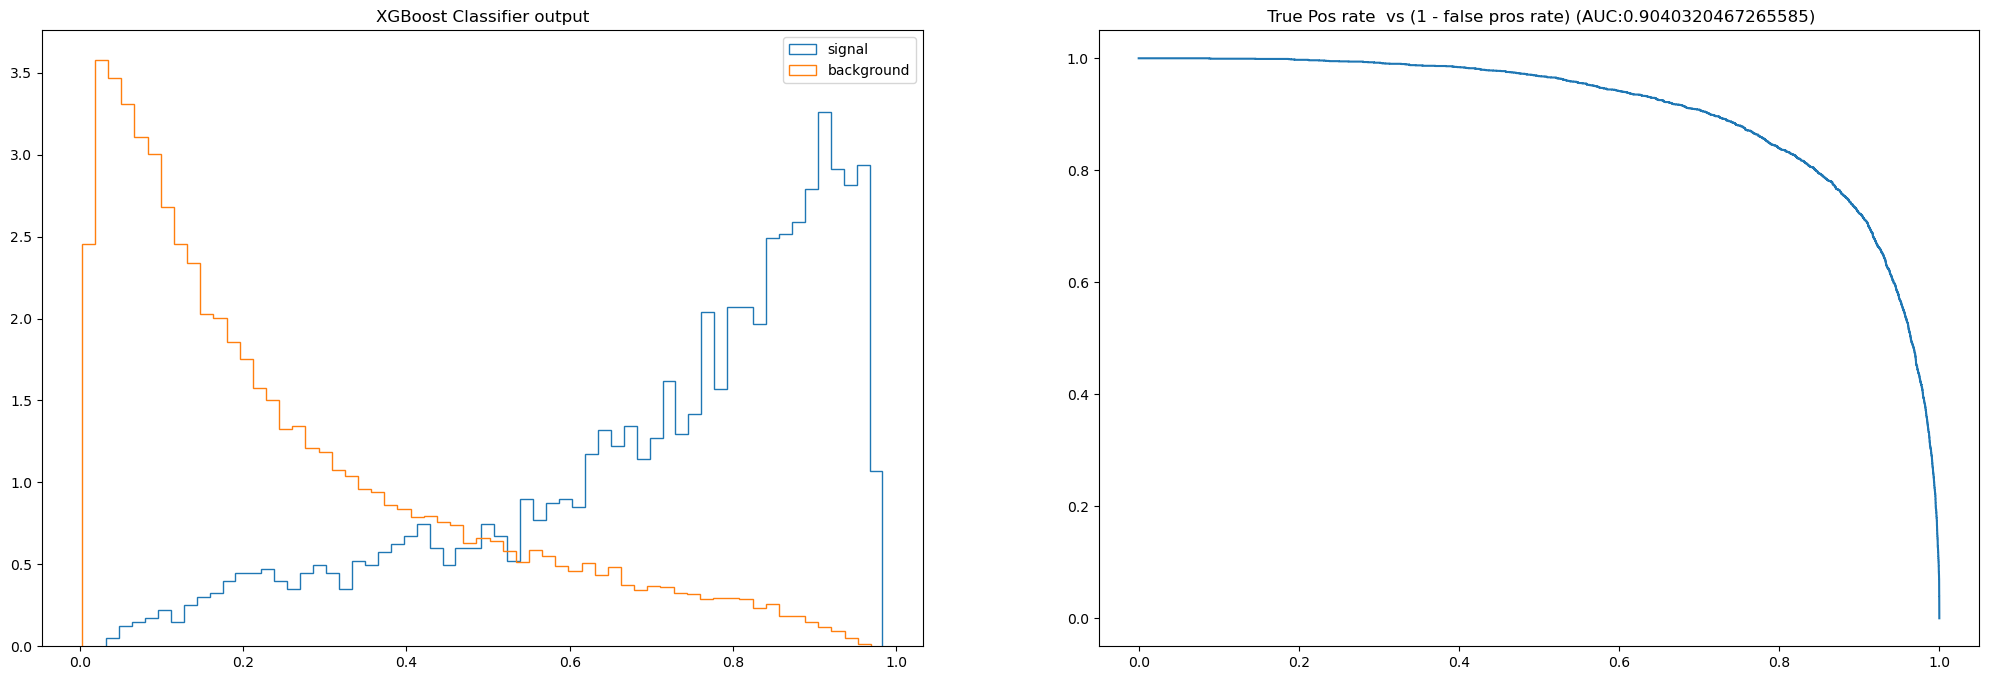

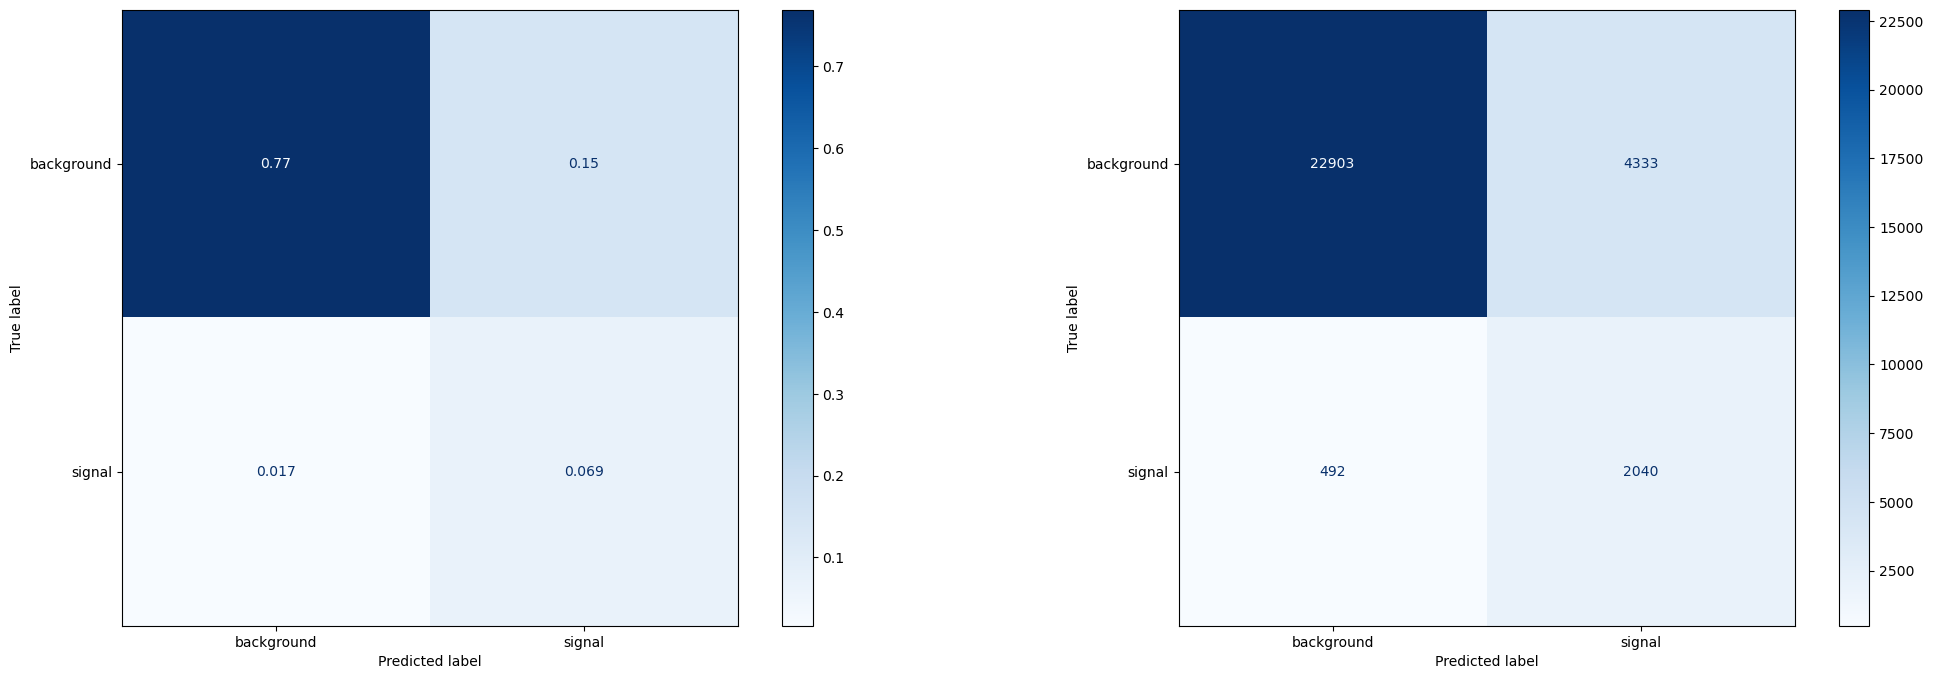

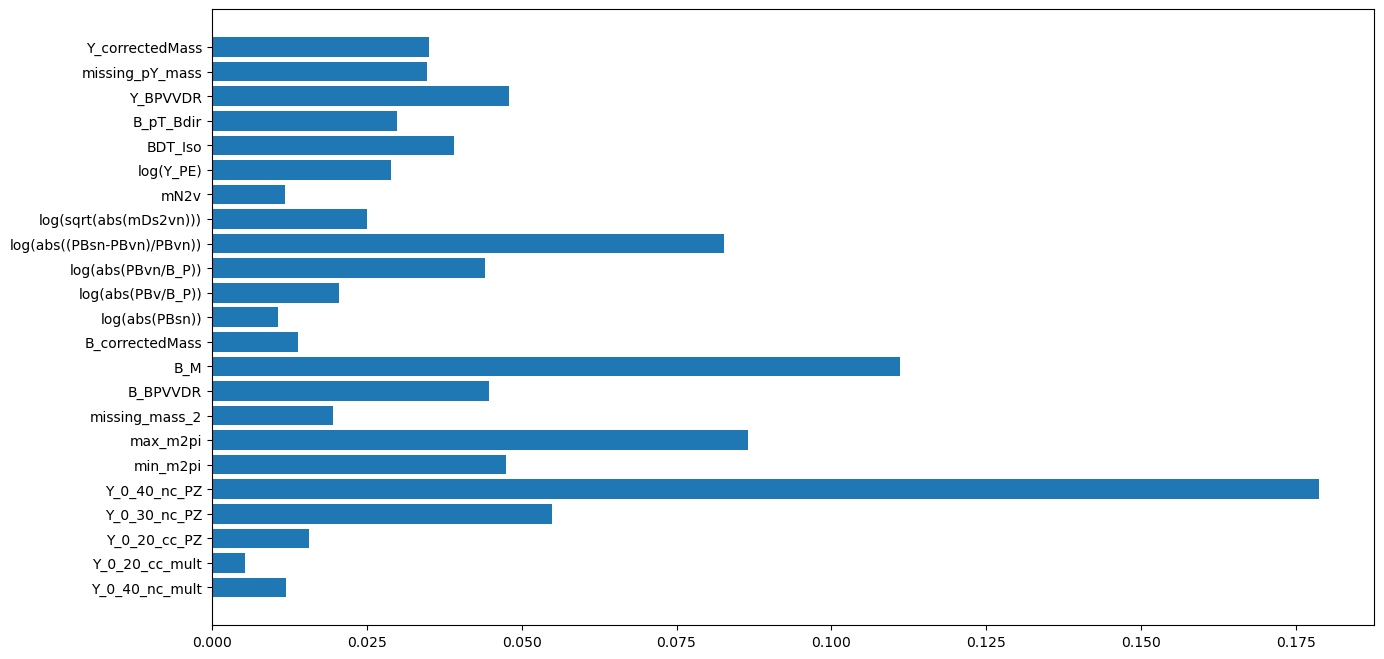

In [21]:
%%time
(Xtrain, ytrain, Xtest, ytest, scaler, Xtrain_scaled, Xtest_scaled) = prepare_data(19)
model, res, xgbclass = train_classifier(Xtrain_scaled, ytrain, Xtest_scaled, ytest)
check_classifier(model, Xtest, ytest)

# Category 20

Ratio bkg=/sign is 4.68747510951812
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.03, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)
[0]	validation_0-logloss:0.68099	validation_1-logloss:0.68124
[1]	validation_0-logloss:0.66955	validation_1-logloss:0.67004
[2]	validation_0-logloss:0.65876	validation_1-logloss:0.65953
[3]	validation_0-logloss:0.648

[118]	validation_0-logloss:0.36632	validation_1-logloss:0.38244
[119]	validation_0-logloss:0.36567	validation_1-logloss:0.38194
[120]	validation_0-logloss:0.36511	validation_1-logloss:0.38152
[121]	validation_0-logloss:0.36453	validation_1-logloss:0.38107
[122]	validation_0-logloss:0.36397	validation_1-logloss:0.38060
[123]	validation_0-logloss:0.36343	validation_1-logloss:0.38013
[124]	validation_0-logloss:0.36271	validation_1-logloss:0.37957
[125]	validation_0-logloss:0.36216	validation_1-logloss:0.37909
[126]	validation_0-logloss:0.36150	validation_1-logloss:0.37858
[127]	validation_0-logloss:0.36091	validation_1-logloss:0.37809
[128]	validation_0-logloss:0.36033	validation_1-logloss:0.37764
[129]	validation_0-logloss:0.35984	validation_1-logloss:0.37721
[130]	validation_0-logloss:0.35935	validation_1-logloss:0.37681
[131]	validation_0-logloss:0.35887	validation_1-logloss:0.37647
[132]	validation_0-logloss:0.35828	validation_1-logloss:0.37596
[133]	validation_0-logloss:0.35774	valid

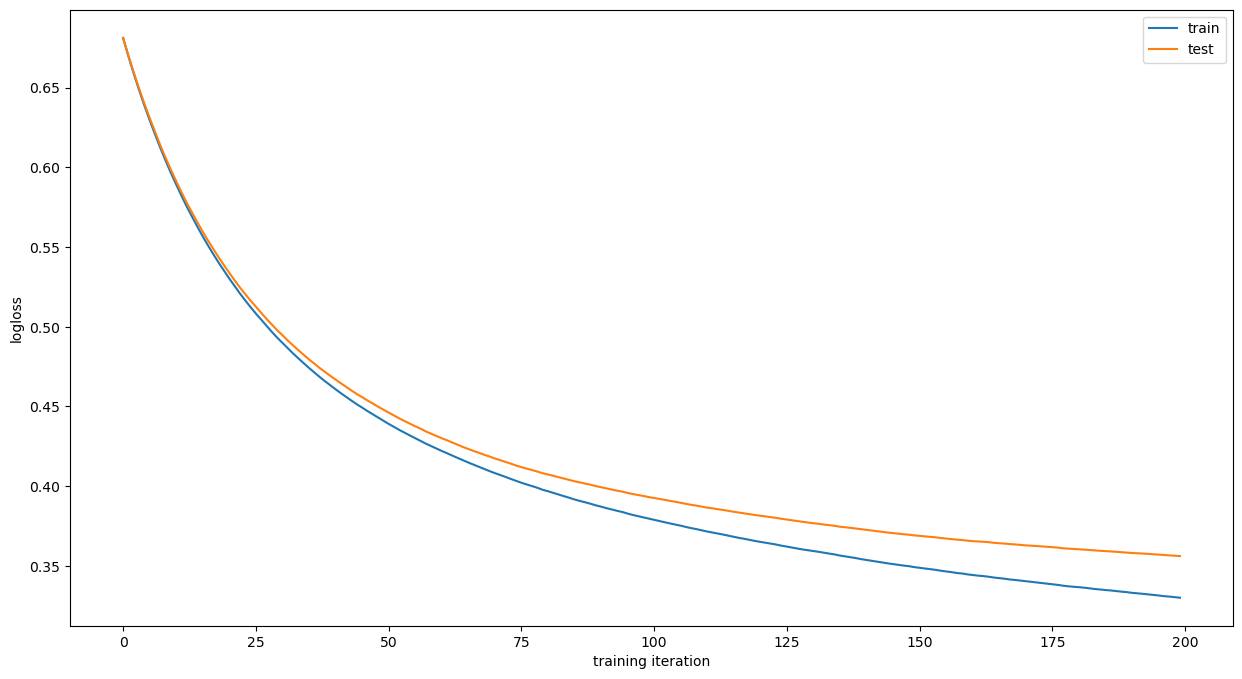

Accuracy: 0.840
0.9137191365986591
CPU times: user 1min 27s, sys: 376 ms, total: 1min 28s
Wall time: 26.7 s


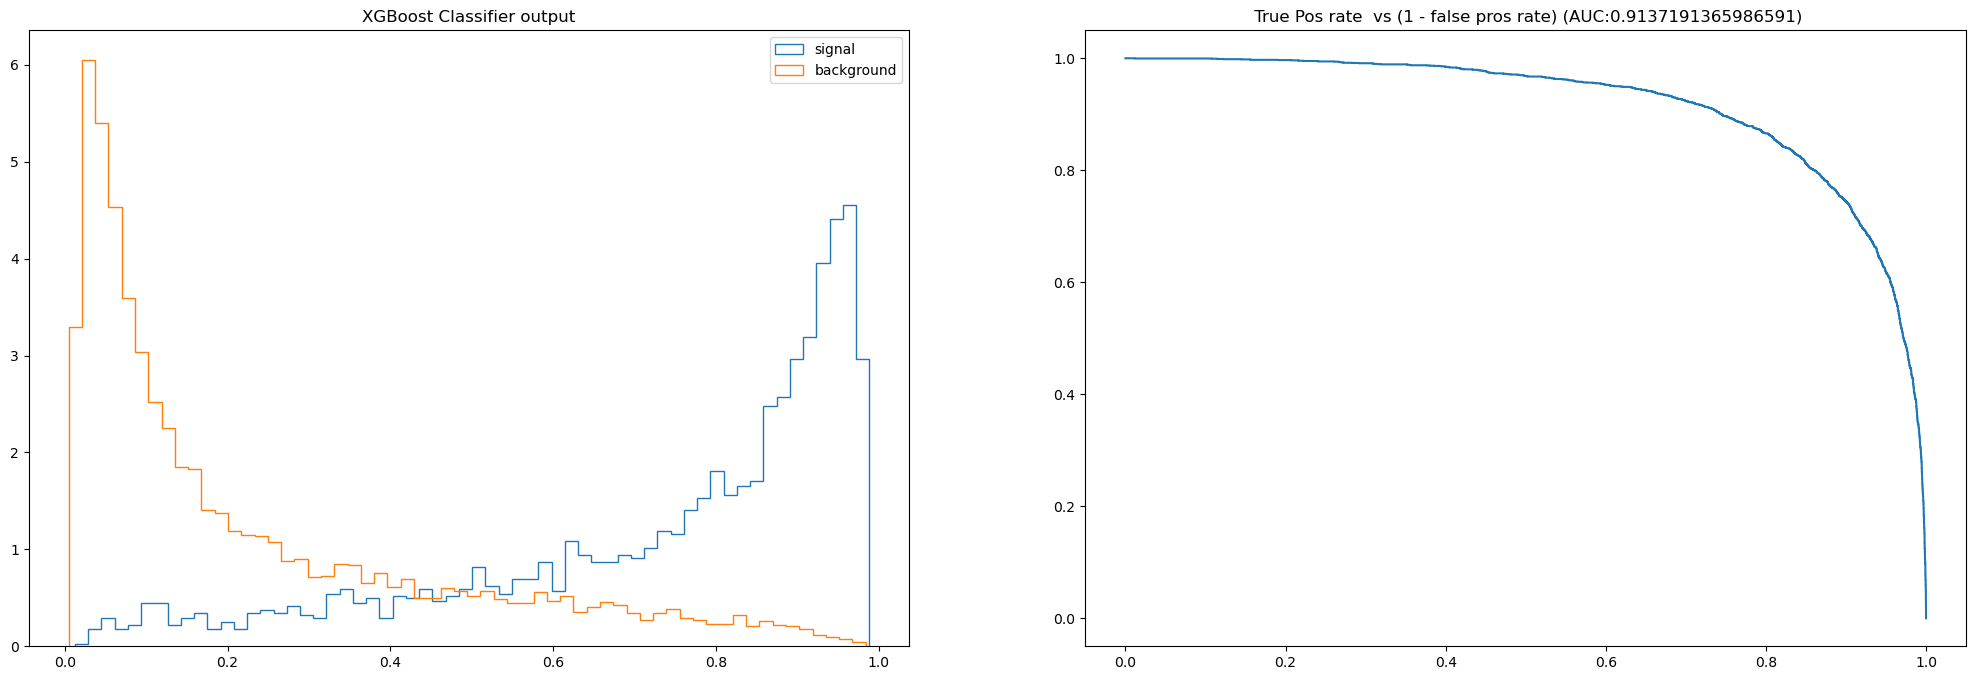

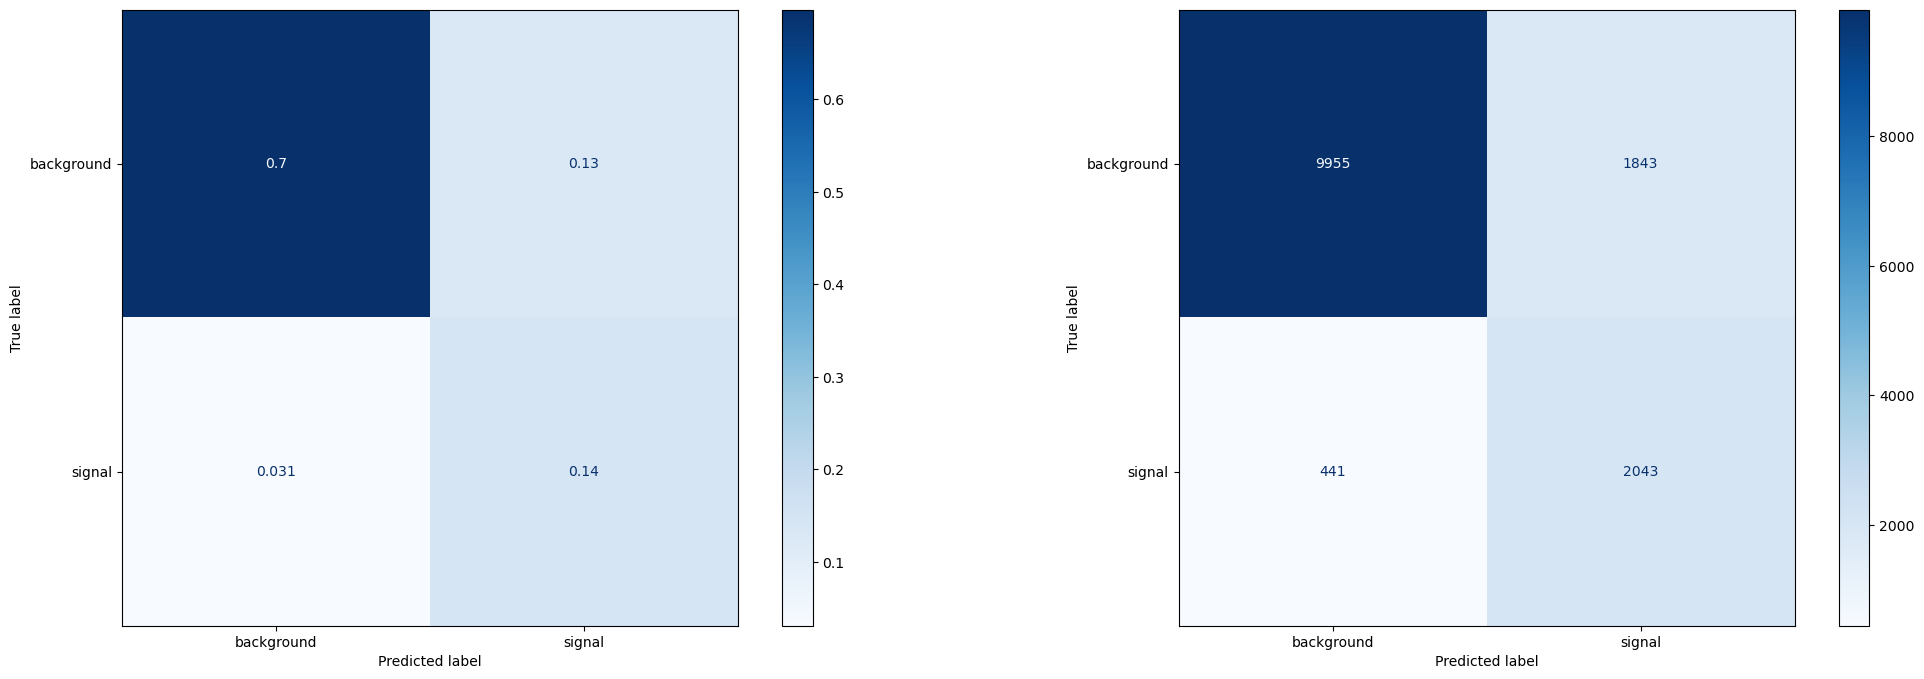

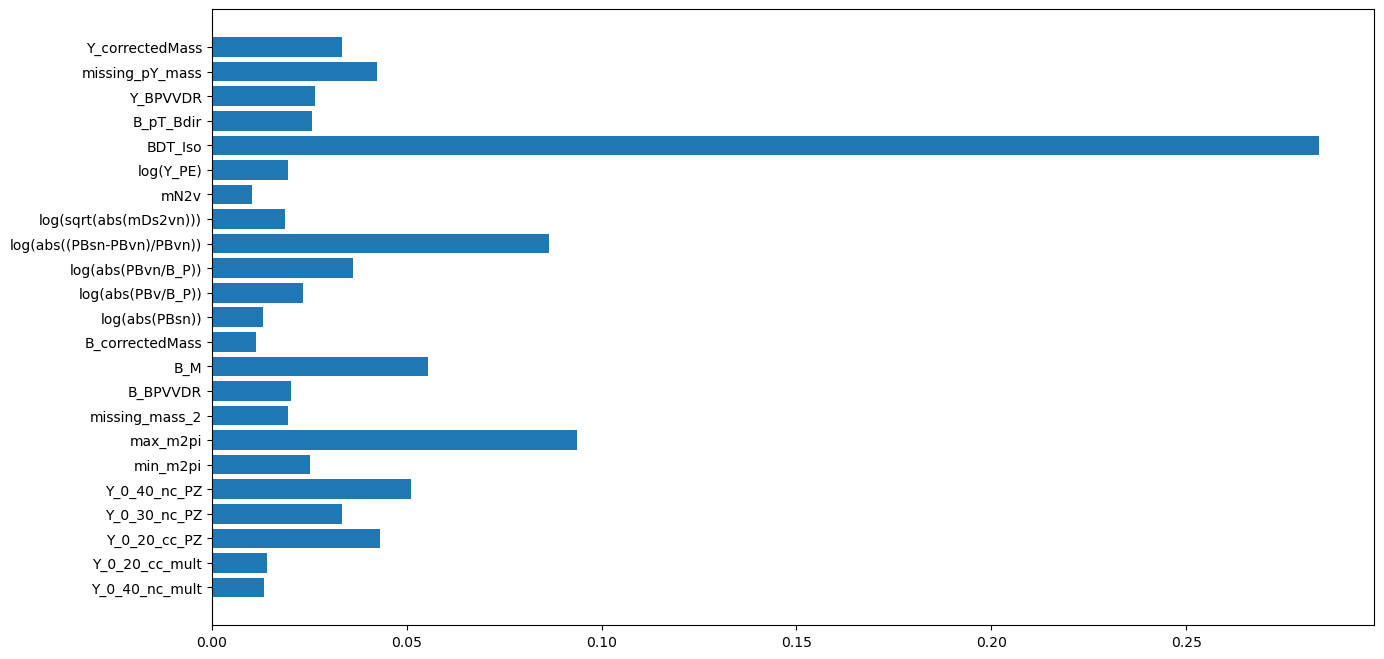

In [22]:
%%time
(Xtrain, ytrain, Xtest, ytest, scaler, Xtrain_scaled, Xtest_scaled) = prepare_data(20)
model, res, xgbclass = train_classifier(Xtrain_scaled, ytrain, Xtest_scaled, ytest)
check_classifier(model, Xtest, ytest)